In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

sns.set_style("whitegrid")

import matplotlib

# set font size to 16
#matplotlib.rcParams.update({"font.size": 16})

SEED = 4

In [2]:
n_runs = 100
# ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]
start_type = "Syn"

#Use the csv files again
#Load accuracy, precision, recall and f1 score
def load_dict_from_csv(filename):
    df = pd.read_csv(filename)
    nested_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        nested_dict.setdefault(run, {})[method] = group['Value'].tolist()
    return nested_dict

#Load time measurements
def load_time_dict_from_csv(filename):
    df = pd.read_csv(filename)
    time_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        pairs = group[['Selection_Time', 'Train_Time']].values.tolist()
        time_dict.setdefault(run, {})[method] = pairs
    return time_dict

#Load type distributions
def load_distributions_dict_from_csv(filename, all_labels):
    df = pd.read_csv(filename)
    dist_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        arrs = group[all_labels].values.tolist()
        dist_dict.setdefault(run, {})[method] = arrs
    return dist_dict

#Load benchmark values
def load_benchmark_dict_from_csv(filename):
    df = pd.read_csv(filename)
    return {col: df[col].dropna().tolist() for col in df.columns}

def get_summary(loaded_dict):
    methods = list(loaded_dict[0].keys())
    summary_dict = {}
    for method in methods:
        all_runs = np.array([loaded_dict[run][method] for run in range(n_runs)]) # shape: (100, array_length)
        # Compute statistics
        mean_values = np.mean(all_runs, axis=0)
        plow_values = np.percentile(all_runs, 10, axis=0)
        phigh_values = np.percentile(all_runs, 90, axis=0)
        # Store in nested structure for easy plotting
        summary_dict[method] = {
            "mean": mean_values.tolist(),
            "plow": plow_values.tolist(),
            "phigh": phigh_values.tolist()
        }
    return summary_dict

benchmark_dict_loaded = load_benchmark_dict_from_csv(f"./results_dictionaries/benchmark_dict_{start_type}_{n_runs}.csv")
accuracy_dict_loaded = load_dict_from_csv( f"./results_dictionaries/accuracy_dict_{start_type}_{n_runs}.csv")
precision_dict_loaded = load_dict_from_csv( f"./results_dictionaries/precision_dict_{start_type}_{n_runs}.csv")
recall_dict_loaded = load_dict_from_csv( f"./results_dictionaries/recall_dict_{start_type}_{n_runs}.csv")
f1score_dict_loaded = load_dict_from_csv( f"./results_dictionaries/f1score_dict_{start_type}_{n_runs}.csv")
time_dict_loaded = load_time_dict_from_csv(f"./results_dictionaries/time_dict_{start_type}_{n_runs}.csv")
all_labels = ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "UDPLag", "Syn"]
distributions_dict_loaded = load_distributions_dict_from_csv(f"./results_dictionaries/distributions_dict_{start_type}_{n_runs}.csv", all_labels)

# Mean Benchmark Values
benchmark_means_dict = {k: np.mean(v) for k, v in benchmark_dict_loaded.items()}
#Mean Accuracy Values
accuracy_summary = get_summary(accuracy_dict_loaded)
# Mean Precision Values
precision_summary = get_summary(precision_dict_loaded)
# Mean Recall Values
recall_summary =  get_summary(recall_dict_loaded)
# Mean F1 Score Values
f1score_summary = get_summary(f1score_dict_loaded)

# Mean Time Measurements
methods = list(time_dict_loaded[0].keys())
mean_time_dict = {}
overall_mean_time_dict = {}
for method in methods:
    # Stack all runs into one array
    all_runs = np.array([time_dict_loaded[run][method] for run in range(n_runs)])  # shape: (100, num_points, 2)
    # Compute mean along runs
    mean_values = np.mean(all_runs, axis=0)  # shape: (num_points, 2)
    mean_time_dict[method] = mean_values
    # Compute overall mean (across all points)
    overall_mean = np.mean(mean_values, axis=0)  # shape: (2,)
    overall_mean_time_dict[method] = overall_mean.tolist()

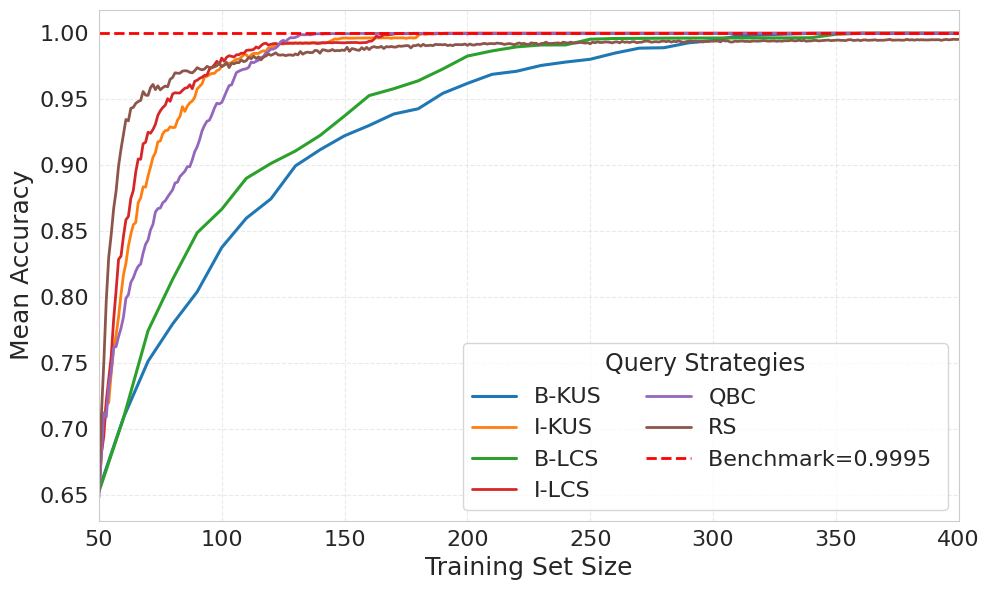

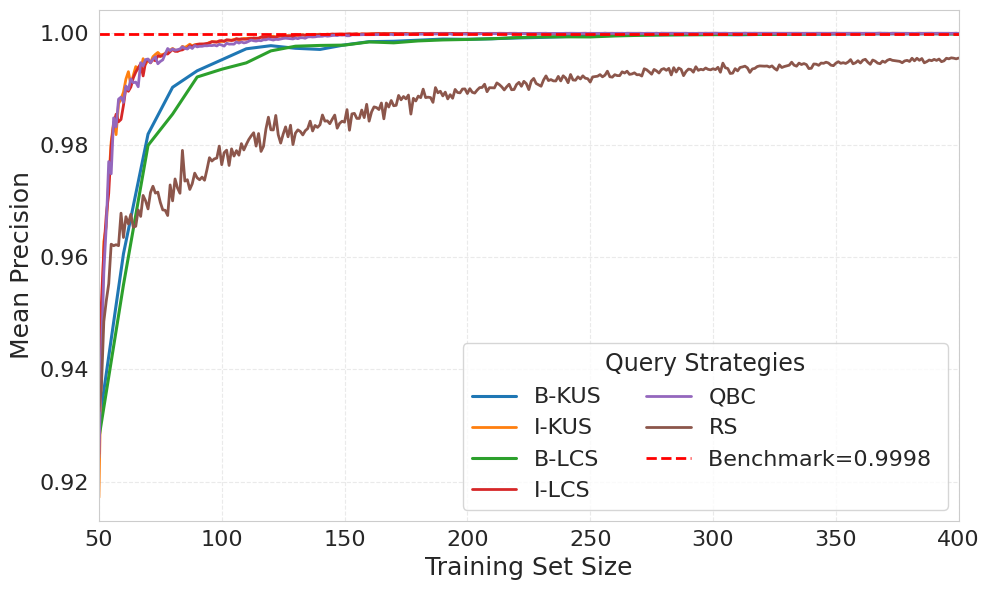

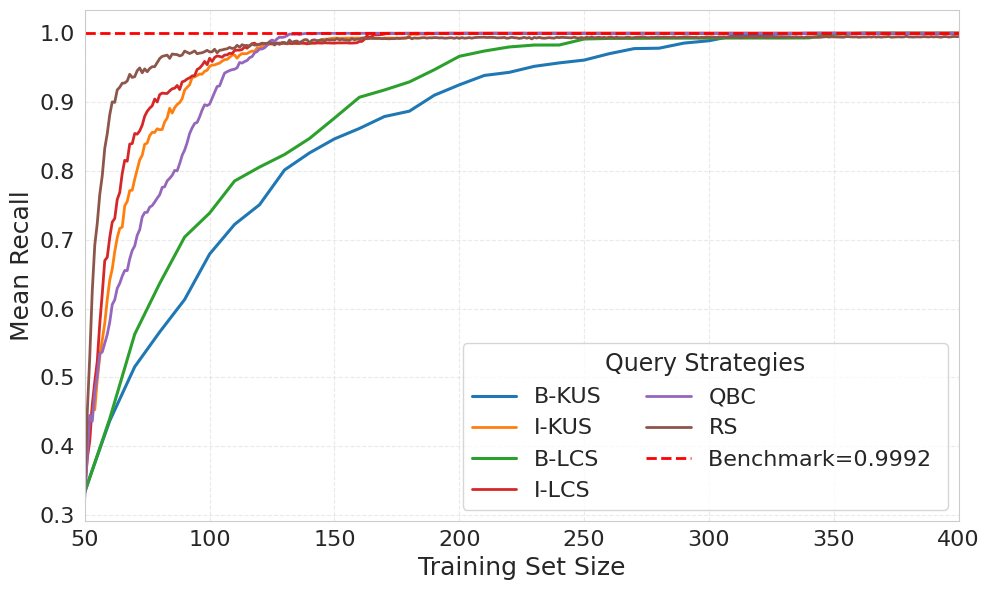

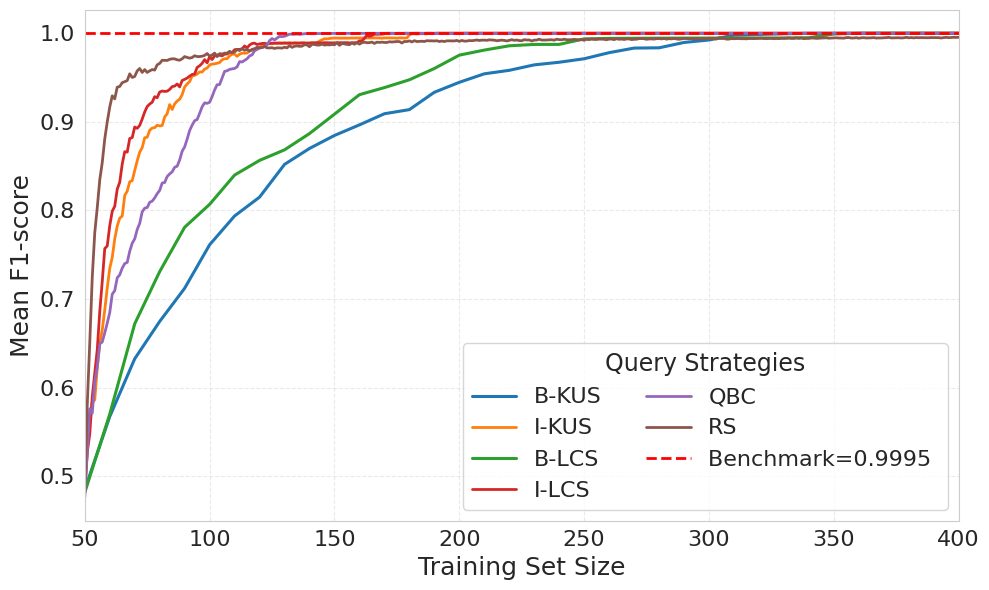

In [3]:
def plot_summary(dict_summary, dict_bench, metric_name):
    dataset_size = np.array(range(50, 401))
    dataset_size_batch = np.array(range(50, 401, 10))
    #method_label = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]
    method_label = ["B-KUS", "I-KUS", "B-LCS", "I-LCS", "QBC", "RS"]

    #Plot
    plt.figure(figsize=(10, 6))
    # Plot each method
    for i, (method, stats) in enumerate(dict_summary.items()):
        mean = np.array(stats["mean"])
        plow = np.array(stats["plow"])
        phigh = np.array(stats["phigh"])
        if len(mean) == len(dataset_size_batch):
            plt.plot(dataset_size_batch, mean,  linewidth=2.2, label=method_label[i])
           # plt.fill_between(dataset_size_batch, plow, phigh, alpha=0.2)
        else:
            plt.plot(dataset_size, mean, linewidth=2, label=method_label[i])    
            #plt.fill_between(dataset_size, plow, phigh, alpha=0.2)

    # Plot the benchmark as asymptote
    benchmark = np.array(dict_bench)
    plt.axhline(y=benchmark, color='red', linestyle='--', linewidth=2, label=f'Benchmark={benchmark:.4f} ')

    # Labels, legend, and styling
    plt.xlim(50, 400)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    plt.xlabel("Training Set Size", fontsize=18)
    plt.ylabel(f"Mean {metric_name}", fontsize=18)
    #plt.title(f"Mean {metric_name} and 10-90 Percentile over 100 Runs for Initial Type " + start_type, fontsize=14, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(fontsize=16, ncol=2, title='Query Strategies', title_fontsize=17, loc = "lower right")
    plt.tight_layout()
    plt.savefig(f"./PROACT_{start_type}/{metric_name}_{start_type}.pdf", bbox_inches='tight')
    plt.show()   

# Plot mean accuracy, precision, recall and f1 score with benchmark
plot_summary(accuracy_summary, benchmark_means_dict["Benchmark_Accuracy"], "Accuracy")
plot_summary(precision_summary, benchmark_means_dict["Benchmark_Precision"], "Precision")
plot_summary(recall_summary, benchmark_means_dict["Benchmark_Recall"], "Recall")
plot_summary(f1score_summary, benchmark_means_dict["Benchmark_F1score"], "F1-score")

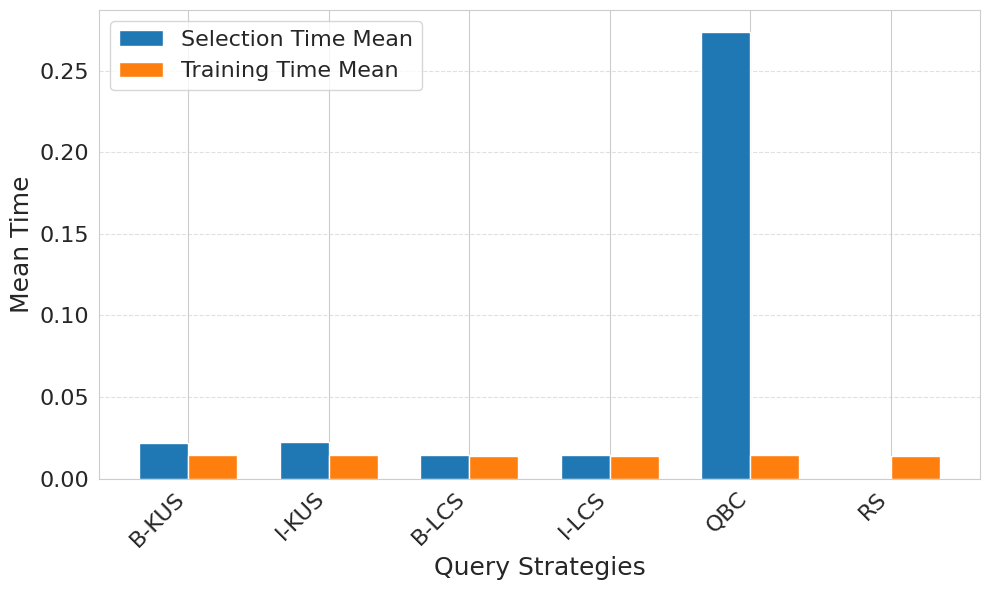

In [4]:
# Plot Mean Times
methods = list(overall_mean_time_dict.keys())
#method_label = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]
method_label = ["B-KUS", "I-KUS", "B-LCS", "I-LCS", "QBC", "RS"]
selection_means = [overall_mean_time_dict[m][0] for m in methods]
train_means = [overall_mean_time_dict[m][1] for m in methods]

# Bar positions
x = np.arange(len(methods))
width = 0.35  # bar width

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, selection_means, width, label='Selection Time Mean')
plt.bar(x + width/2, train_means, width, label='Training Time Mean')

plt.xlabel('Query Strategies', fontsize=18)
plt.ylabel('Mean Time', fontsize=18)
#plt.title(f'Average Selection and Training Times per Query Strategy ({start_type}, {n_runs} runs)', fontsize=16)
plt.xticks(x, method_label, rotation=45, ha='right',fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16, loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig(f"./PROACT_{start_type}/time_{start_type}.pdf", bbox_inches='tight')
plt.show()


In [5]:
#Get the mean sorting
results_summary = {}
f1score_summary_mean = defaultdict(lambda: None)
for method in f1score_summary.keys():
    if len(f1score_summary[method]["mean"]) == 351:
        f1score_summary_mean[method]= np.array(f1score_summary[method]["mean"])[::10]
        f1score_summary_mean[method] = np.array(f1score_summary_mean[method])[1:]
    else:
        f1score_summary_mean[method] = np.array(f1score_summary[method]["mean"])[1:]



methods = list(f1score_summary_mean.keys())

# Flatten per method into (method, index, value)
f1_events = []
for method in methods:
    values = np.array(f1score_summary_mean[method])
    for i, v in enumerate(values):
        f1_events.append((method, i, v))
    
# Sort events by iteration (index)
f1_events.sort(key=lambda x: x[1])
    
# Track first >=0.95 and first/second >=0.99
first_95 = None
first_99 = None
second_99 = None
third_99 = None
seen_99_methods = set()
    
for method, idx, val in f1_events:
    if first_95 is None and val >= 0.95:
        first_95 = (method, idx)
    if val >= 0.99 and method not in seen_99_methods:
        seen_99_methods.add(method)
        if first_99 is None:
            first_99 = (method, idx)
        elif second_99 is None:
            second_99 = (method, idx)
        elif third_99 is None:
            third_99 = (method, idx)
    if first_95 and first_99 and second_99 and third_99:
        break

# Find the training set lengths at each Benchmark Point
results_summary = {
    "first_95_method": first_95[0] if first_95 else None,
    "first_95_index": first_95[1] if first_95 else None,
    "first_99_method": first_99[0] if first_99 else None,
    "first_99_index": first_99[1] if first_99 else None,
    "second_99_method": second_99[0] if second_99 else None,
    "second_99_index": second_99[1] if second_99 else None,
    "third_99_index": third_99[1] if third_99 else None,
    "third_99_method": third_99[0] if third_99 else None
}

In [6]:
# Calculate distributions at specific dataset sizes
methods = list(distributions_dict_loaded[0].keys())
# Containers for distributions at each threshold
all_distr_len = defaultdict(lambda: defaultdict(list))
mean_distr_len = defaultdict(lambda: defaultdict(list))

datasize = [results_summary["first_95_index"], results_summary["first_99_index"], results_summary["second_99_index"], results_summary["third_99_index"]]
idx_batch = list(range(0,35))
idx_single = [i*10 + 9 for i in idx_batch]
#[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

for run in range(n_runs):
    for method in methods:
        distr_arr = np.array(distributions_dict_loaded[run][method])
        for k in datasize:
            if len(distr_arr) == 350:
                all_distr_len[k][method].append(distr_arr[idx_single[k]])
            else:
                all_distr_len[k][method].append(distr_arr[idx_batch[k]])

#Mean Distrbiutions at each benchmark points
for siz in datasize: 
    for method in methods: 
        mean_distr_len[siz][method] = np.mean(all_distr_len[siz][method], axis = 0)

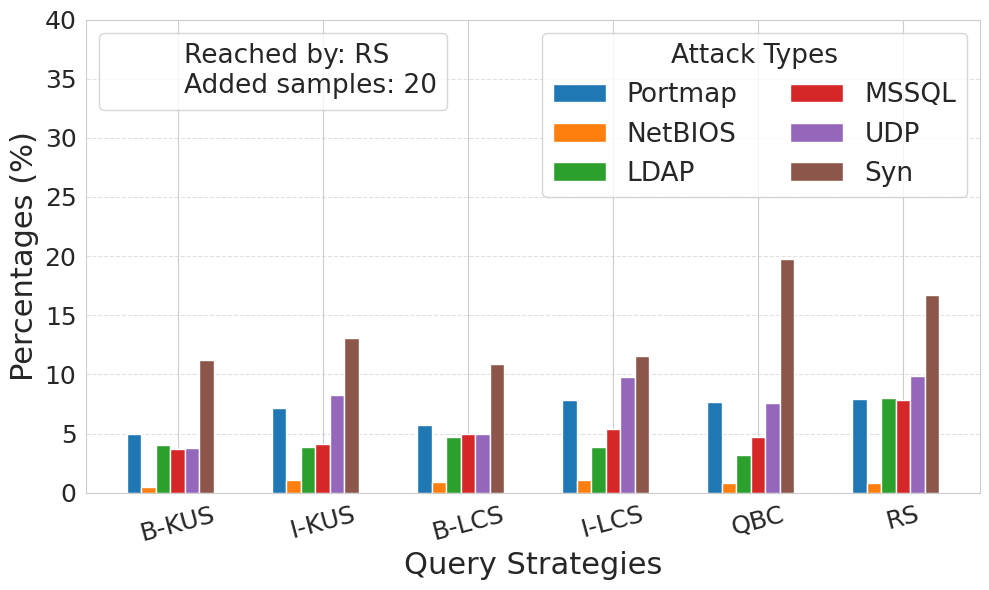

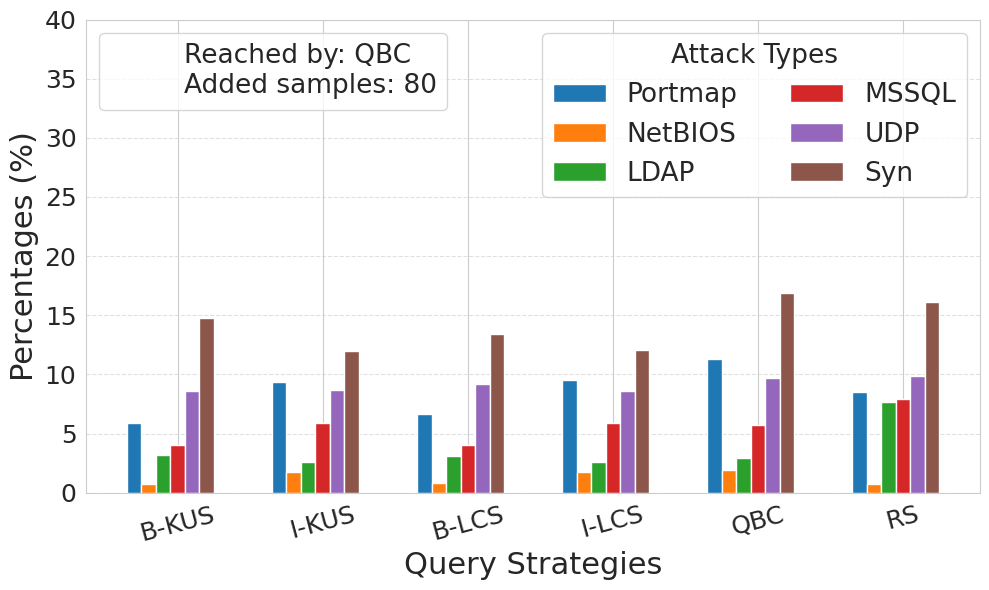

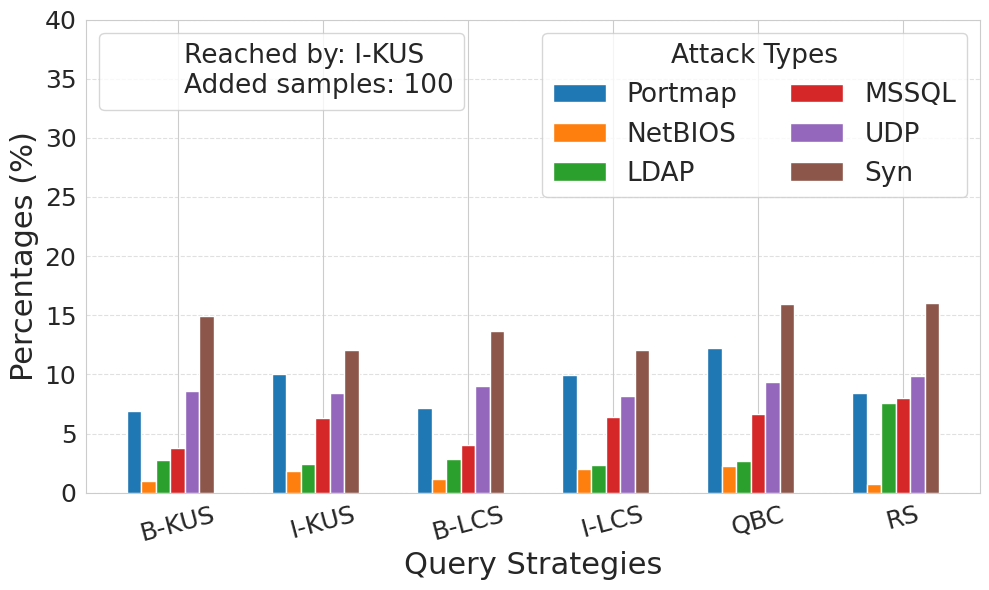

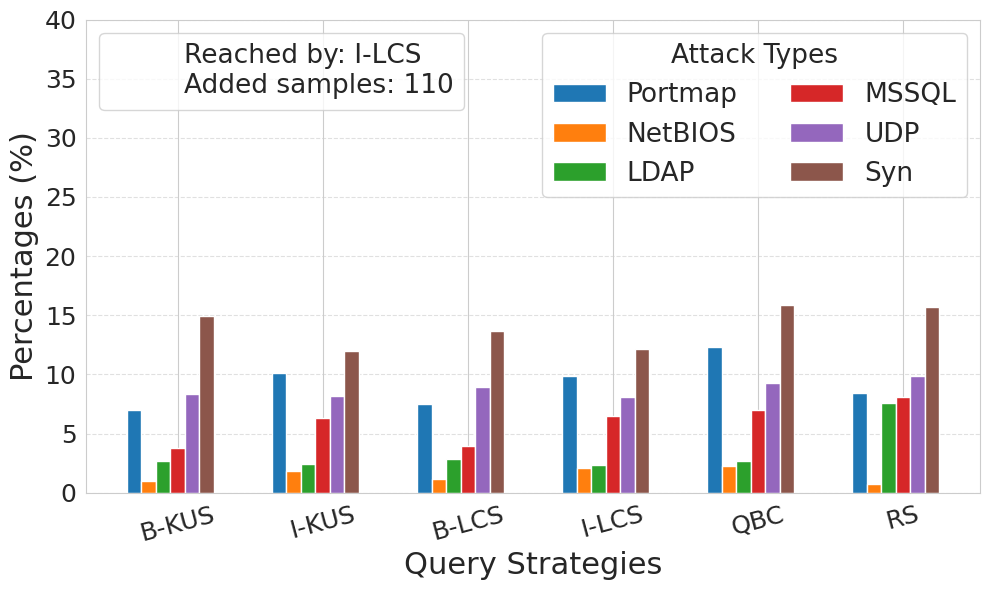

'\n                       f"Mean Distribution at Third 99% F1 Score (Start: {start_type}, {n_runs} runs)",                            extra_info=None)\n\n                       extra_info=(results_summary["third_99_method"], results_summary["third_99_index"]))                            f"Mean Distribution at Train Size Length {siz} (Start: {start_type}, {n_runs} runs)",\n\n#Compute for fixed length    plot_mean_distribution(mean_distr_len[siz], \n\n'

In [ ]:
def plot_mean_distribution(mean_dict, title, extra_info=None, bm_nb = None):
    #methods = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]
    methods = ["B-KUS", "I-KUS", "B-LCS", "I-LCS", "QBC", "RS"]
    categories = ["Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]

    # Mapping from internal method names (keys in mean_dict) to display labels
    method_name_mapping = {
        "KU_batch": "B-KUS",
        "KU_single": "I-KUS",
        "Predictproba_batch": "B-LCS",
        "Predictproba_single": "I-LCS",
        "QBC": "QBC",
        "Random": "RS"
    }

    data = np.array([
        mean_dict["KU_batch"],
        mean_dict["KU_single"],
        mean_dict["Predictproba_batch"],
        mean_dict["Predictproba_single"],
        mean_dict["QBC"],
        mean_dict["Random"]
    ])

    data = np.delete(data, [0, 6], axis=1)  # remove Benign + UDPLag

    x = np.arange(len(methods))
    width = 0.1
    plt.figure(figsize=(10, 6))

    bar_handles = []
    # Draw category bars
    for i, category in enumerate(categories):
        bars = plt.bar(x + (i - len(categories)/2) * width, data[:, i], width, label=category)
        bar_handles.append(bars[0])

    # Main legend (categories only)
    category_legend = plt.legend(handles=bar_handles,
                                 labels=categories,
                                 fontsize=19,
                                 loc='upper right',
                                 ncol=2,
                                 title='Attack Types',
                                 title_fontsize=19)
    plt.gca().add_artist(category_legend)

    # Extra info legend (separate) — map internal method name to display label
    if extra_info is not None:
        method_name, idx = extra_info
        display_name = method_name_mapping.get(method_name, method_name)
        extra_label = f"Reached by: {display_name}\nAdded samples: {(idx+1)*10}"

        plt.legend(
            handles=[plt.Line2D([0], [0], color='white')],  # invisible handle
            labels=[extra_label],
            loc="upper left",
            frameon=True,
            fontsize=19,
        )

    plt.xticks(x, methods, rotation=15, fontsize=18)
    plt.yticks(fontsize=18)
    plt.ylabel("Percentages (%)",fontsize=22)
    plt.xlabel("Query Strategies", fontsize=22)
    #plt.title(title, fontsize=14)
    plt.ylim(0, 40)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"./PROACT_{start_type}/BM{bm_nb}_{start_type}.pdf", bbox_inches='tight')
    plt.show()

plot_mean_distribution(mean_distr_len[datasize[0]], 
                       f"Mean Distribution at First Strategy Reaching 95% F1 Score (Init_DDoS: {start_type}",
                       extra_info=(results_summary["first_95_method"], results_summary["first_95_index"]), bm_nb=1)

plot_mean_distribution(mean_distr_len[datasize[1]], 
                       f"Mean Distribution at First Strategy Reaching 99% F1 Score (Init_DDoS: {start_type})",
                       extra_info=(results_summary["first_99_method"], results_summary["first_99_index"]), bm_nb=2)

plot_mean_distribution(mean_distr_len[datasize[2]], 
                       f"Mean Distribution at Second Strategy Reaching 99% F1 Score (Init_DDoS: {start_type})",
                       extra_info=(results_summary["second_99_method"], results_summary["second_99_index"]), bm_nb=3)

plot_mean_distribution(mean_distr_len[datasize[3]], 
                       f"Mean Distribution at Third Strategy Reaching 99% F1 Score (Init_DDoS: {start_type})",
                       extra_info=(results_summary["third_99_method"], results_summary["third_99_index"]), bm_nb=4)